In [1]:
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras import backend as K
# import needed to create custom activation function
import pydot

In [2]:
df = pd.read_csv('./haberman.csv')
df.head()

,x1,x2,x3,y
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1


In [3]:
df.loc[df['y'] == 1, 'y'] = -1
df.loc[df['y'] == 2, 'y'] = 1
print(df.head(10))

   x1  x2  x3  y
0  30  64   1 -1
1  30  62   3 -1
2  30  65   0 -1
3  31  59   2 -1
4  31  65   4 -1
5  33  58  10 -1
6  33  60   0 -1
7  34  59   0  1
8  34  66   9  1
9  34  58  30 -1


In [4]:
X = df.iloc[:, 0:3]
Y = df.iloc[:, 3]

X = (X - X.mean()) / X.std()
X.head()

,x1,x2,x3
0,-2.078735,0.353006,-0.420903
1,-2.078735,-0.262492,-0.142725
2,-2.078735,0.660755,-0.559991
3,-1.986172,-1.185738,-0.281814
4,-1.986172,0.660755,-0.003636


In [5]:
trainingSetSize = int(0.8 * X.shape[0])
X_train = X.iloc[0:trainingSetSize, :]
Y_train = Y.iloc[0:trainingSetSize]
X_test = X.iloc[trainingSetSize:, :]
Y_test = Y.iloc[trainingSetSize:]
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(244, 3)
(244,)
(62, 3)
(62,)


/Users/mihtriii/Documents/GitHub/DAP391m/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


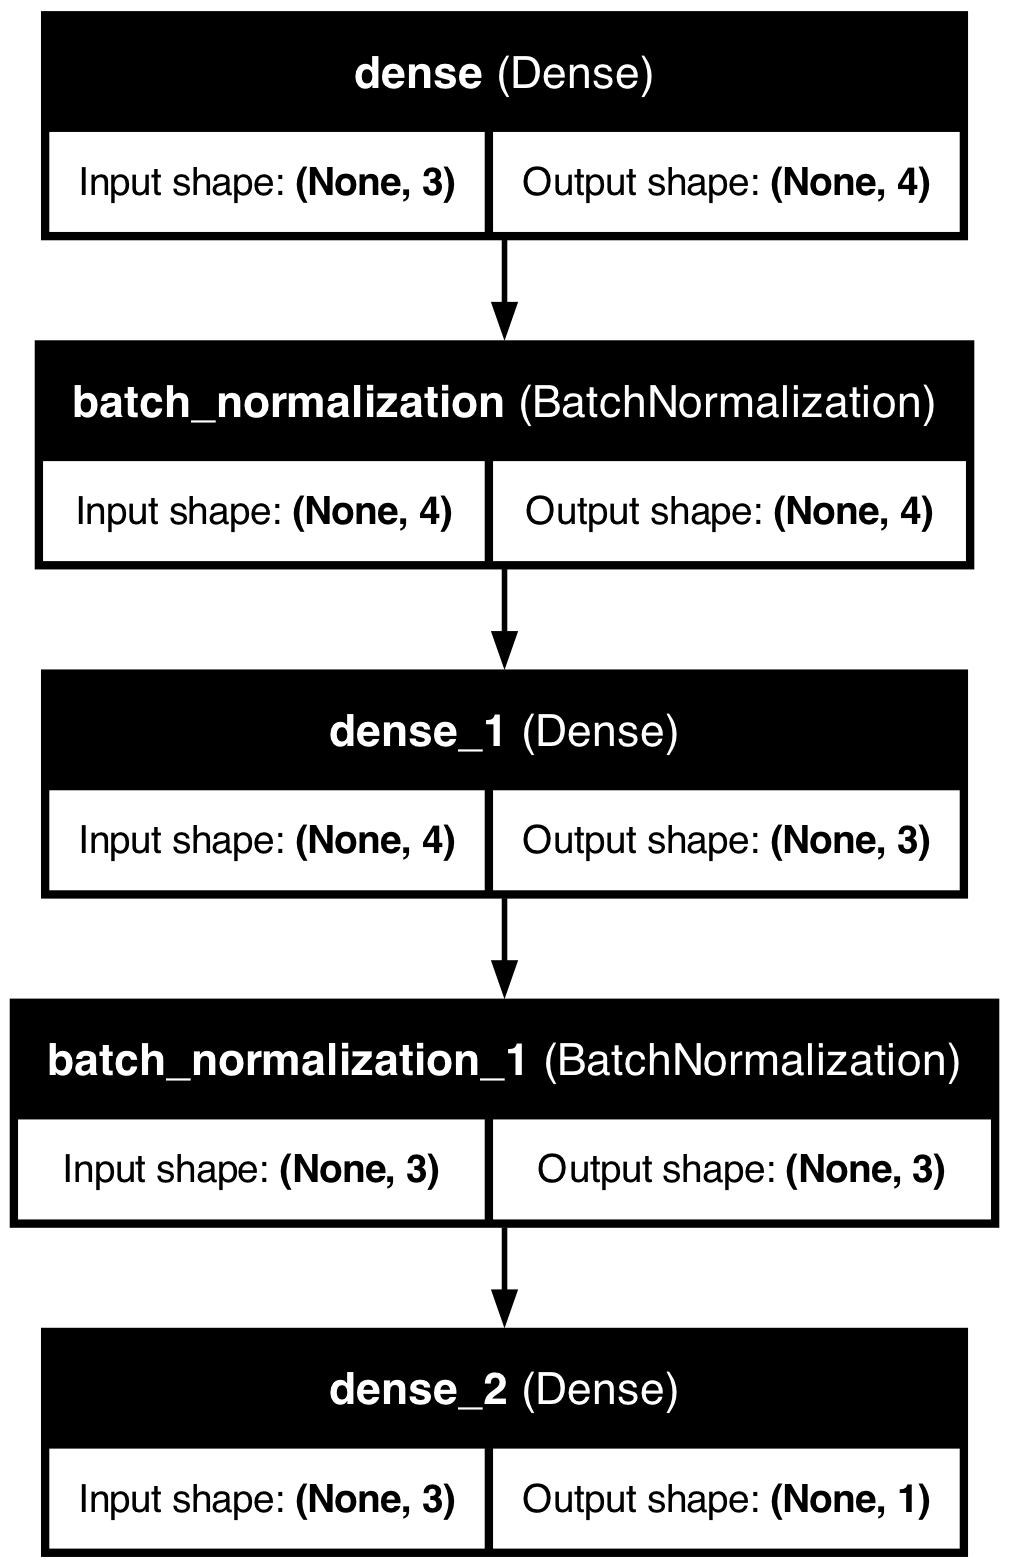

In [6]:
import os
import pydot
import graphviz
from IPython.display import display, Image
from matplotlib import pyplot
from keras.models import Sequential
from keras.utils import plot_model
from keras import backend
from keras.layers import Dense, Dropout, Flatten, Activation, BatchNormalization

def rmse(y_true, y_pred):
    return backend.sqrt(backend.mean(backend.square(y_pred - y_true)))

os.makedirs('model', exist_ok=True)

nn_model = Sequential()
nn_model.add(Dense(4, input_dim=3, activation='relu'))
nn_model.add(BatchNormalization())
nn_model.add(Dense(3, activation='tanh'))
nn_model.add(BatchNormalization())
nn_model.add(Dense(1, activation='tanh'))
nn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

plot_model(nn_model, to_file='./model/model.png', show_shapes=True, show_layer_names=True)
display(Image(filename='model/model.png'))

In [7]:
from scipy import stats

# Train the nn model
history = nn_model.fit(X_train.values, Y_train.values, epochs=450, batch_size=10, verbose=0)

# Evaluate the model on the training set
results_train = nn_model.evaluate(X_train.values, Y_train.values)
print('Loss function value - training set:', results_train[0])
print('Metrics value - training set:', results_train[1])

# Predict values in the training set
Y1_pred = nn_model.predict(X_train.values)

# Assign category -1 or 1 basing on the predicted values - training set
Y1_pred[Y1_pred >= 0] = 1
Y1_pred[Y1_pred < 0] = -1

print("Success rate(%) - training set:", 100 * np.sum(Y1_pred[:, 0] == Y_train.values) / len(Y_train))
print("Number of obs. per category in Y_train - training_set")

# Thay thế stats.itemfreq bằng np.unique
values, counts = np.unique(Y_train.values, return_counts=True)
print(np.asarray((values, counts)).T)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: -7.7398  
Loss function value - training set: -7.7398152351379395
Metrics value - training set: 0.0
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Success rate(%) - training set: 75.0
Number of obs. per category in Y_train - training_set
[[ -1 179]
 [  1  65]]


In [8]:
Y2_pred = nn_model.predict(X_test.values)
Y2_pred[Y2_pred >= 0] = 1
Y2_pred[Y2_pred < 0] = -1

print("Success rate(%) - test set:", 100 * np.sum(Y2_pred[:, 0] == Y_test.values) / len(Y_test))
print("Number of obs. per category in Y_test - test_set")
values, counts = np.unique(Y_test.values, return_counts=True)
print(np.asarray((values, counts)).T)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Success rate(%) - test set: 74.19354838709677
Number of obs. per category in Y_test - test_set
[[-1 46]
 [ 1 16]]


In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [12]:
# Load dataset (no header in original file)
cols = [
    "Class","age","menopause","tumor-size","inv-nodes",
    "node-caps","deg-malig","breast","breast-quad","irradiat"
]

df = pd.read_csv("breast-cancer.data", names=cols)
df["Class"] = df["Class"].map({
    "no-recurrence-events": 0,
    "recurrence-events": 1
})

# Column meanings (ID, diagnosis, 30 features)
X = df.drop("Class", axis=1)
y = df["Class"].values
X = pd.get_dummies(X)

In [13]:
# Convert diagnosis to binary
y = np.where(y == 'M', 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

input_size = X_train.shape[1]
print(input_size)   # usually ~43 features after encoding

41


In [14]:
import torch.nn as nn

class BC_NN(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = BC_NN(input_size)

In [15]:
import torch.optim as optim

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 200

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 20, Loss: 0.4451
Epoch 40, Loss: 0.3661
Epoch 60, Loss: 0.2933
Epoch 80, Loss: 0.2309
Epoch 100, Loss: 0.1770
Epoch 120, Loss: 0.1311
Epoch 140, Loss: 0.0933
Epoch 160, Loss: 0.0644
Epoch 180, Loss: 0.0449
Epoch 200, Loss: 0.0325


In [16]:
model.eval()
with torch.no_grad():
    preds = (model(X_test) >= 0.5).float()

accuracy = (preds.eq(y_test).sum().item()) / len(y_test)
print("Test Accuracy:", accuracy * 100)

Test Accuracy: 100.0
